# Analysis — Tier 1: the coarse cause-risk allocator

Builds and evaluates **Tier 1** of the hierarchical model: a coarse allocator that predicts a
region-season's **burned-area composition across three classes — Human / Natural / Unknown** (on a
total-acres denominator, so the shares sum to 1). The three branch deep-dives (Natural → location,
Human → sub-cause, Unknown → data quality) hang off this allocation. Rationale:
[`../coursework/W4/design_refinement.md`](../coursework/W4/design_refinement.md).

**Input.** `data/region_season_cause.parquet` — the cleaned analysis grain (EPA Level III ecoregion
× meteorological season × season-year × cause), with the missing-cause mass in `missing_acres` so
the Unknown class is recoverable.

Predicted and actual compositions are compared with **total variation distance (TVD)** — the share
of the composition sitting in the wrong class — reported unweighted and acre-weighted (the
deliverable ranks by burned acres).

The winning baseline, pointed at the *next* unobserved season-year and paired with a
total-burned-acres prediction, is the **next-season cause-risk profile**: the expected composition
of causes for a region's upcoming season, ranked by the acres each is expected to drive, with the
predicted Unknown share carried alongside as an attribution-quality signal.

In [1]:
# Analysis — load the region-season-cause grain
import sys

import pandas as pd

sys.path.insert(0, "../src")
from config import ProjectConfig
from panel import RegionSeasonPanel

# Paths, the boundary rule, the forward-chaining split and the locked shares window come
# from src/config.py.
cfg = ProjectConfig()
DATA = cfg.data

# RegionSeasonPanel owns the load, the partial-winter boundary rule, the coarse
# Human/Natural/Unknown mapping, and the per-cell dedup of the missing-cause mass.
# `panel.raw` is the grain as loaded; `panel.rsc` has the boundary rule applied.
panel = RegionSeasonPanel.load(cfg)

print(f"{len(panel.raw):,} rows  |  {panel.raw.region.nunique()} regions x "
      f"{panel.raw.season.nunique()} seasons x {panel.raw.cause.nunique()} causes")
panel.raw.head()

123,312 rows  |  105 regions x 4 seasons x 12 causes


,region,season_year,season,season_idx,cause,acres,fires,cell_acres,cause_share,missing_acres,missing_fires,missing_acre_frac
0,Acadian Plains and Hills,1992,JJA,2,Arson/incendiarism,15.82,9,36.98,0.427799,9.6,5.0,0.206097
1,Acadian Plains and Hills,1992,JJA,2,Debris and open burning,2.95,4,36.98,0.079773,9.6,5.0,0.206097
2,Acadian Plains and Hills,1992,JJA,2,Equipment and vehicle use,5.80,12,36.98,0.156842,9.6,5.0,0.206097
3,Acadian Plains and Hills,1992,JJA,2,Firearms and explosives use,0.00,0,36.98,0.000000,9.6,5.0,0.206097
4,Acadian Plains and Hills,1992,JJA,2,Fireworks,0.00,0,36.98,0.000000,9.6,5.0,0.206097


## Boundary rule — drop the two partial winters

Meteorological winter (DJF) is labelled by the year it *ends*, so it spans the prior December plus
January–February. The record runs 1992-01-01 → 2020-12-31, which truncates the two winters at the
ends:

- **`season_idx = 0`** (1992 DJF) is missing its December 1991 — only Jan–Feb 1992 is observed.
- **`season_idx = 116`** (2021 DJF) is missing its Jan–Feb 2021 — only December 2020 is observed.

Both are half-seasons by construction. `season_idx = 116` matters most: it falls in the held-out
tail (≥ 2010), so leaving it in would score the model against a structurally-incomplete winter.
Dropping both removes 141 cells, 1.37% of the 10,276, leaving all 28 *full* DJF winters intact.
Applied right after the load, so every downstream target, baseline and score inherits it.

In [2]:
# The two partial winters, season_idx 0 and 116, truncated by the record's 1992-01-01 /
# 2020-12-31 endpoints. RegionSeasonPanel applied the drop on load.
rsc = panel.rsc
PARTIAL_WINTERS = list(cfg.partial_winters)

print(f"dropped partial winters season_idx {PARTIAL_WINTERS}: "
      f"{panel.cells_dropped} region-season cells removed "
      f"({panel.cells_before:,} -> {panel.cells_after:,})")
print(f"season_idx now {rsc.season_idx.min()}-{rsc.season_idx.max()} | "
      f"{rsc[rsc.season=='DJF'].season_idx.nunique()} full DJF winters remain")

dropped partial winters season_idx [0, 116]: 141 region-season cells removed (10,276 -> 10,135)
season_idx now 1-115 | 28 full DJF winters remain


In [3]:
# Coarse three-way classifier: Human / Natural / Unknown
#   Natural  = the single 'Natural' cause
#   Human    = all other resolved causes (incl. 'Other causes')
#   Unknown  = the missing-cause mass, held in missing_acres (NOT a cause row)
# Denominator is TOTAL burned acres = cell_acres + missing_acres, so the three shares sum to 1
# -- unlike cause_share, which conditions on attribution.
print(rsc.drop_duplicates("cause")[["cause", "coarse"]].sort_values(["coarse", "cause"]).to_string(index=False))

                                     cause  coarse
                        Arson/incendiarism   Human
                   Debris and open burning   Human
                 Equipment and vehicle use   Human
               Firearms and explosives use   Human
                                 Fireworks   Human
                 Misuse of fire by a minor   Human
                              Other causes   Human
Power generation/transmission/distribution   Human
       Railroad operations and maintenance   Human
                   Recreation and ceremony   Human
                                   Smoking   Human
                                   Natural Natural


In [4]:
# Snapshot: total acres across the three coarse classes
# Unknown comes from the per-cell missing_acres, DEDUPLICATED to one value per cell so it
# isn't summed 12x (summing gives 397.5M acres instead of the correct 33.1M).

snapshot = panel.class_acre_snapshot()

print(snapshot.assign(
    acres=snapshot["acres"].round(0),
    Macres=snapshot["Macres"].round(2),
    share=(snapshot["share"] * 100).round(1).astype(str) + "%",
).to_string())
print(f"\nTotal burned acres: {snapshot['acres'].sum()/1e6:,.2f}M")

               acres  Macres  share
Human     40525592.0   40.53  22.6%
Natural  105522888.0  105.52  58.9%
Unknown   33068953.0   33.07  18.5%

Total burned acres: 179.12M


## Is the cause composition static or dynamic?

**Hypothesis.** Three persistence baselines establish the floor and settle whether the target has
season-to-season structure:

- **`t-4` (same season last year):** predict this cell = its own value one year ago. The truest
  persistence; maximally responsive, but a single heavy-tailed year is noisy.
- **Trailing mean (k=3):** mean of the last 3 same-season occurrences. Averages out single-megafire
  swings but lags real trends.
- **Expanding mean:** mean of *all* prior same-season occurrences — the long-run climatological
  composition, the most static possible baseline.

If the means beat `t-4`, the target is stable and the signal is in its long-run average. If `t-4`
wins, there is real season-to-season structure a learned temporal model could exploit.

**Experiment.** The Tier-1 target is a three-way composition per region-season by burned-area share
on a total-acres denominator — one point on the 2-simplex per cell. All three baselines use only
past season-years (forward-chaining); scoring is on the held-out tail with TVD, unweighted and
acre-weighted.

In [5]:
# One 3-class composition per (region, season_idx). Denominator is TOTAL burned acres =
# resolved (Human+Natural) + Unknown (missing_acres), so the three sum to 1 -- a valid point
# on the 2-simplex. The panel builds it and asserts the sum.

CLASSES = list(cfg.tier1_classes)
tier1 = panel.tier1_composition()

print(f"{len(tier1):,} region-season cells | season_years {tier1.season_year.min()}-{tier1.season_year.max()}")
print(tier1[CLASSES].describe().round(3).to_string())
tier1.head()

10,135 region-season cells | season_years 1992-2020
           human    natural    unknown
count  10135.000  10135.000  10135.000
mean       0.592      0.170      0.238
std        0.352      0.308      0.280
min        0.000      0.000      0.000
25%        0.269      0.000      0.014
50%        0.678      0.005      0.118
75%        0.924      0.150      0.376
max        1.000      1.000      1.000


,region,season,season_idx,season_year,human_ac,natural_ac,unknown_ac,total_ac,human,natural,unknown,log_total
0,Acadian Plains and Hills,DJF,8,1994,0.20,0.0,0.00,0.20,1.000000,0.0,0.000000,-0.698970
1,Acadian Plains and Hills,DJF,32,2000,0.20,0.0,1.01,1.21,0.165289,0.0,0.834711,0.082785
2,Acadian Plains and Hills,DJF,40,2002,1.22,0.0,0.00,1.22,1.000000,0.0,0.000000,0.086360
3,Acadian Plains and Hills,DJF,48,2004,0.50,0.0,0.00,0.50,1.000000,0.0,0.000000,-0.301030
4,Acadian Plains and Hills,DJF,56,2006,10.45,0.0,2.60,13.05,0.800766,0.0,0.199234,1.115611


In [6]:
# Three forward-chaining predictors: for a target cell they use ONLY same-region, same-season
# occurrences at strictly earlier season_idx. Same season last year is season_idx - 4.
#
# Both classes assert the frame is sorted by (region, season, season_idx) before computing --
# on an unsorted frame the raw shift-then-roll idiom silently attaches one region's history to
# another's rows, with no NaN and no error.
#
# T4Predictor is NOT TrailingMean(k=1): it additionally requires the prior occurrence to be a
# true t-4 step (no missing season-year), so it is scored on fewer, gap-free cells.
from trailing import T4Predictor, TrailingMean

tier1 = tier1.sort_values(list(cfg.sort_keys)).reset_index(drop=True)

pred = {
    "t4": T4Predictor().predict(tier1, CLASSES),
    "mean3": TrailingMean(3).predict(tier1, CLASSES),
    "expanding": TrailingMean(None).predict(tier1, CLASSES),
}

# Each prediction is a valid simplex point by construction (mean of simplex points is a simplex
# point); confirm none drifted off the simplex where defined.
for name, p in pred.items():
    s = p.dropna().sum(axis=1)
    assert (s.sub(1).abs() < 1e-9).all(), f"{name}: predictions must sum to 1 where defined"
    print(f"{name:10s}: {p.notna().all(axis=1).sum():>5,} cells predictable "
          f"({p.isna().any(axis=1).sum():,} unscored -- no prior history)")

t4        : 9,355 cells predictable (780 unscored -- no prior history)
mean3     : 9,733 cells predictable (402 unscored -- no prior history)
expanding : 9,733 cells predictable (402 unscored -- no prior history)


In [7]:
# TVD = 1/2 * sum|pred - actual| across the 3 shares -- the simplex distance, in [0,1]:
# 0 = identical composition, 1 = disjoint. Reported unweighted and acre-weighted (the product
# ranks by acres).
import numpy as np

# Score only cells whose season_year >= this; every baseline still trains purely on
# strictly-earlier years.
TEST_START = cfg.test_start

actual = tier1[CLASSES].to_numpy()
in_test = (tier1["season_year"] >= TEST_START).to_numpy()
w = tier1["total_ac"].to_numpy()

rows = []
for name, p in pred.items():
    P = p.to_numpy()
    tvd = 0.5 * np.abs(P - actual).sum(axis=1)          # per-cell TVD (NaN where unpredictable)
    m = in_test & ~np.isnan(tvd)                        # scorable test cells
    rows.append({
        "baseline": name,
        "n_cells": int(m.sum()),
        "TVD_unweighted": float(tvd[m].mean()),
        "TVD_acre_wtd": float(np.average(tvd[m], weights=w[m])),
    })

scores = pd.DataFrame(rows).set_index("baseline")
print(f"Held-out tail: season_year >= {TEST_START}\n")
print(scores.round(4).to_string())
print("\nLower TVD = better. mean beats t-4 -> static target; t-4 beats mean -> dynamic.")

Held-out tail: season_year >= 2010

           n_cells  TVD_unweighted  TVD_acre_wtd
baseline                                        
t4            3803          0.3138         0.331
mean3         3949          0.2775         0.278
expanding     3949          0.2710         0.284

Lower TVD = better. mean beats t-4 -> static target; t-4 beats mean -> dynamic.


**Finding.** **The target is static.** Both averaging baselines beat `t-4` by ~5 TVD points on the
held-out tail (season-year ≥ 2010), settling the static-vs-dynamic question: a region-season's cause
composition is stable, and a single prior year is mostly tail noise — one megafire swings it, the
means wash it out.

A learned *temporal* model therefore has little to exploit. Any lift must come **cross-sectionally**
— region and season features, external covariates — not from dynamics. `t-4` is scored on fewer
cells by design, since it skips gap-prone series, which makes its loss more telling rather than less.

Between the two averaging baselines the call is close: trailing-3 edges the expanding mean on the
acre-weighted metric but they flip on the unweighted score. The window `k` is swept next.

## Is trailing-3 the right window?

**Hypothesis.** The trailing mean edged the expanding mean on the acre-weighted metric but they flip
unweighted, so `k=3` is unverified. A flat curve across `k` means the window barely matters; a clear
minimum locates the real floor.

**Experiment.** Sweep `k` from 1 (the immediately-prior same-season occurrence) through the
expanding limit, scoring each with the same forward-chaining split and both TVD metrics.

In [8]:
# Sweep k over {1..8} plus the expanding limit, scored the same way (forward-chaining, held-out
# tail, both TVD metrics). k=1 reduces to the immediately-prior same-season value, which differs
# from the `t4` baseline: that one requires a true t-4 step, so k=1 here is scored on more,
# gap-tolerant cells.

K_GRID = list(range(1, 9))

def score_trailing(window):
    """TVD for a trailing mean of `window` prior same-season occurrences (None -> expanding)."""
    P = TrailingMean(window).predict(tier1, CLASSES).to_numpy()
    tvd = 0.5 * np.abs(P - actual).sum(axis=1)
    m = in_test & ~np.isnan(tvd)
    return int(m.sum()), float(tvd[m].mean()), float(np.average(tvd[m], weights=w[m]))

ksweep = pd.DataFrame(
    [dict(zip(["n_cells", "TVD_unweighted", "TVD_acre_wtd"], score_trailing(k)))
     for k in K_GRID] +
    [dict(zip(["n_cells", "TVD_unweighted", "TVD_acre_wtd"], score_trailing(None)))],
    index=[f"k={k}" for k in K_GRID] + ["expanding"],
)

best_unw = ksweep["TVD_unweighted"].idxmin()
best_wtd = ksweep["TVD_acre_wtd"].idxmin()
print(ksweep.round(4).to_string())
print(f"\nbest unweighted: {best_unw}   |   best acre-weighted: {best_wtd}  (this one governs)")

           n_cells  TVD_unweighted  TVD_acre_wtd
k=1           3949          0.3138        0.3305
k=2           3949          0.2844        0.2983
k=3           3949          0.2775        0.2780
k=4           3949          0.2736        0.2799
k=5           3949          0.2703        0.2737
k=6           3949          0.2694        0.2673
k=7           3949          0.2678        0.2663
k=8           3949          0.2671        0.2677
expanding     3949          0.2710        0.2840

best unweighted: k=8   |   best acre-weighted: k=7  (this one governs)


**Finding.** **More history is better — trailing-3 is not the minimum.** Across `k=1..8`, all on
the same 4,024 test cells, TVD falls monotonically as the window widens, well past `k=3`. The
acre-weighted minimum — the metric that governs, since the deliverable ranks by acres — is **k=7 at
0.266**, with k=6–8 essentially tied and all beating k=3 by ~1 TVD point.

This sharpens the static read: not only do averages beat `t-4`, averaging over **more** years keeps
helping. The composition is stable enough that ~7 same-season years is the sweet spot.

The **expanding** mean is *worse* than k=6–8, so pulling in the very oldest years (early 1990s) adds
noise rather than signal — an unbounded window overshoots.

**Lock the trailing mean at k=7.** The floor is **~27% of the composition misplaced** (acre-weighted).
Whether that is good enough is a planner's question; it is the bar every later rung must beat.

## Can total burned acres be predicted from history?

**Hypothesis.** The shares baseline answers *what fraction* of a region-season's burn each class
drives, but the deliverable ranks classes by **acres**, which needs a second prediction:
`predicted acres_class = predicted_share_class × predicted_total_acres`.

**Experiment.** Total acres is not a share on `[0,1]` — across the 10,276 cells it spans from a
hundredth of an acre to ~2.9M, eight-plus orders of magnitude. Scored in raw acres a handful of
cells would swamp everything, and "off by 500 acres" means something different at a 5-acre cell than
at a 500,000-acre one. So the level is predicted and scored in **log₁₀ space**: target
`log₁₀(total_ac)`, error as **MAE/RMSE in orders of magnitude** — a log-MAE of 0.30 reads as
"typically off by a factor of ~2." The `total_ac > 0` filter already removed every zero cell, so no
epsilon is needed.

Same forward-chaining machinery and split as the shares, with `k` re-swept rather than assumed to
transfer, since the level's tail need not behave like the composition's.

In [9]:
# Target = log10(total_ac). A trailing mean of log-acres is the geometric mean of the raw acres,
# the right center for a multiplicatively heavy-tailed quantity. k is re-swept rather than
# inherited from the shares, since the level's tail need not match the composition's.

tier1["log_total"] = np.log10(tier1["total_ac"])            # safe: total_ac > 0 already enforced
log_actual = tier1["log_total"].to_numpy()                 # reuse in_test, w from the shares scoring

def score_level(window):
    """log-space MAE/RMSE for a trailing mean of `window` prior same-season log-acres (None -> expanding)."""
    p = TrailingMean(window).predict(tier1, "log_total")["log_total"].to_numpy()
    err = np.abs(p - log_actual)
    m = in_test & ~np.isnan(err)
    return {
        "n_cells": int(m.sum()),
        "logMAE_unwtd": float(err[m].mean()),
        "logMAE_acre_wtd": float(np.average(err[m], weights=w[m])),
        "logRMSE_unwtd": float(np.sqrt((err[m] ** 2).mean())),
    }

level_sweep = pd.DataFrame(
    [score_level(k) for k in K_GRID] + [score_level(None)],
    index=[f"k={k}" for k in K_GRID] + ["expanding"],
)
best_level = level_sweep["logMAE_acre_wtd"].idxmin()       # acre-weighted governs, as for shares
print(level_sweep.round(4).to_string())
print(f"\nbest acre-weighted log-MAE: {best_level}   "
      f"(a log-MAE of {level_sweep.loc[best_level, 'logMAE_acre_wtd']:.3f} "
      f"= typically off by ~{10 ** level_sweep.loc[best_level, 'logMAE_acre_wtd']:.1f}x on acres)")

           n_cells  logMAE_unwtd  logMAE_acre_wtd  logRMSE_unwtd
k=1           3949        0.7997           1.0668         1.1099
k=2           3949        0.7147           0.9424         0.9730
k=3           3949        0.6770           0.9430         0.9195
k=4           3949        0.6632           0.9631         0.8938
k=5           3949        0.6479           0.9484         0.8791
k=6           3949        0.6378           0.9360         0.8663
k=7           3949        0.6421           0.9659         0.8716
k=8           3949        0.6435           0.9768         0.8695
expanding     3949        0.6465           1.0850         0.8653

best acre-weighted log-MAE: k=6   (a log-MAE of 0.936 = typically off by ~8.6x on acres)


In [10]:
# predicted acres-per-class = predicted_share x predicted_total_acres. Shares from the locked
# k=7 trailing mean; the level from its own best window, back-transformed out of log space. Both
# forward-chaining, so every profile uses only strictly-earlier same-season history.

# `shares_k` is named for its target, not a generic default: the LEVEL re-sweeps independently
# and lands on k=6, and the Human branch sweeps a different grid.
SHARE_K = cfg.shares_k
pred_share = TrailingMean(SHARE_K).predict(tier1, CLASSES)

level_window = None if best_level == "expanding" else int(best_level.split("=")[1])
pred_log = TrailingMean(level_window).predict(tier1, "log_total")["log_total"]
pred_total = 10 ** pred_log                                 # back to acres

# acres-per-class = share x total; ranking the three by this column IS the cause-risk profile.
profile = tier1[["region", "season", "season_idx", "season_year"]].copy()
for c in CLASSES:
    profile[f"pred_ac_{c}"] = pred_share[c] * pred_total
    profile[f"actual_ac_{c}"] = tier1[c] * tier1["total_ac"]
profile["pred_total_ac"] = pred_total
profile["actual_total_ac"] = tier1["total_ac"]

# How often the predicted #1 class by acres matches the actual #1 -- the profile's headline.
pred_cols = [f"pred_ac_{c}" for c in CLASSES]
act_cols = [f"actual_ac_{c}" for c in CLASSES]
scored = profile[in_test & pred_share.notna().all(axis=1) & pred_log.notna()].copy()
pred_top = scored[pred_cols].to_numpy().argmax(axis=1)
act_top = scored[act_cols].to_numpy().argmax(axis=1)
top1 = (pred_top == act_top)
# acre-weighted: does the profile get the *big* region-seasons' dominant class right?
top1_wtd = np.average(top1, weights=scored["actual_total_ac"])

print(f"held-out profiles scored: {len(scored):,}")
print(f"top-1 class agreement (which class drives the most acres):")
print(f"   unweighted    {top1.mean():.1%}")
print(f"   acre-weighted {top1_wtd:.1%}   <- weights the big-burn region-seasons")

# The largest-burn held-out cell, as a planner would read it.
ex = scored.loc[scored["actual_total_ac"].idxmax()]
print(f"\nexample profile -- {ex['region']} / {ex['season']} / season-year {int(ex['season_year'])}:")
ranked = sorted(CLASSES, key=lambda c: ex[f"pred_ac_{c}"], reverse=True)
for c in ranked:
    print(f"   {c:8s}  predicted {ex[f'pred_ac_{c}']:>12,.0f} ac   |   actual {ex[f'actual_ac_{c}']:>12,.0f} ac")

held-out profiles scored: 3,949
top-1 class agreement (which class drives the most acres):
   unweighted    70.1%
   acre-weighted 72.7%   <- weights the big-burn region-seasons

example profile -- Interior Forested Lowlands and Uplands / JJA / season-year 2015:
   natural   predicted       68,570 ac   |   actual    2,826,326 ac
   unknown   predicted          809 ac   |   actual       75,143 ac
   human     predicted           85 ac   |   actual            0 ac


**Finding.** The product is complete in shape: for a region and upcoming season it now predicts
both the cause mix and the total burn, and multiplying them gives expected acres per cause, ranked.
All of it uses only prior years, scored on 2010 onward.

**The mix is predictable.** ~27% of the composition lands in the wrong class (acre-weighted) — the
bar any smarter model has to beat.

**The level is not.** The same trailing-mean rule is **typically off by ~9× on total acres** in the
seasons that burn big. Interior Forested Lowlands, summer 2015 burned **2.8M acres**; the trailing
mean predicted ~69,000 — roughly 40× low. Averaging calm prior years cannot anticipate a
record-breaking fire year, because big years are driven by that season's weather and dryness, not by
how the region behaved before.

**Top-1 accuracy is 73% acre-weighted, with a caveat.** Naming the right #1 class is easier than it
sounds: in the West, Natural almost always dominates, so "guess Natural in the West" scores well
without being informative. The real test is the region-seasons where the leading cause actually
changes.

**What this establishes.** This is the floor, using only past history. The cause mix is stable and
predictable; the total size is not, from history alone. Remaining lift has to come from the upcoming
season's conditions — weather, dryness, fuels — which is the external-data direction the branch
notebooks open.

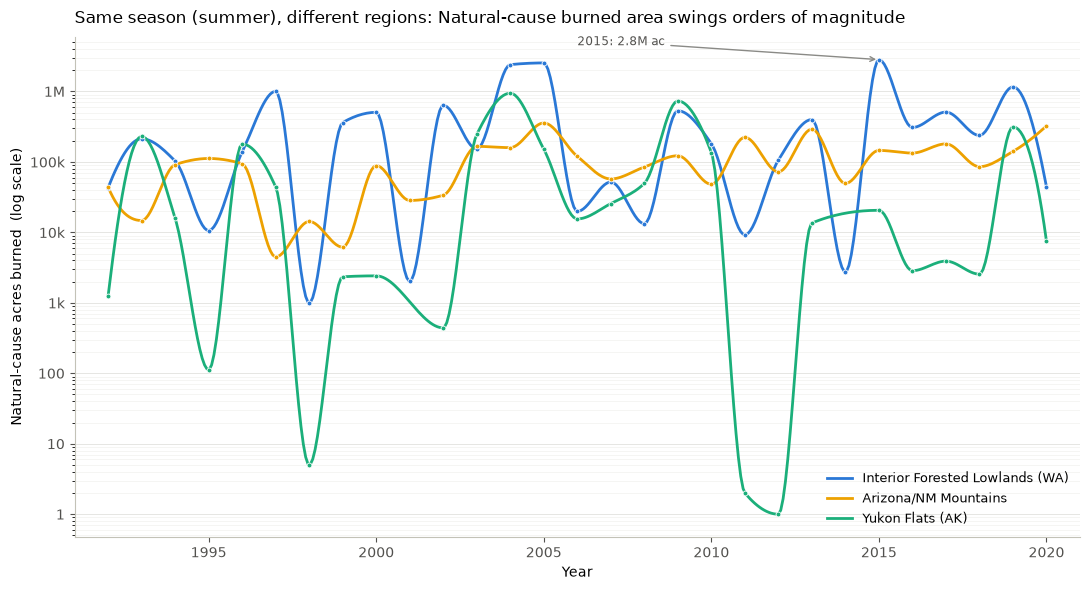

In [11]:
# Natural-season size swings wildly and differently from region to region. All three series are
# SUMMER (JJA), so the contrast is purely region-to-region. Log axis: the only way ~1-acre and
# ~2.8M-acre years fit on one figure. Lines are a monotone cubic (PCHIP) through the ACTUAL yearly
# points -- cosmetic smoothing that never overshoots or invents a peak; every real value stays on
# the line.
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator

nat_ac = rsc[rsc["cause"] == "Natural"].groupby(["region", "season", "season_year"])["acres"].sum()

# Three summer regions contrasting scale and volatility: a megafire-spiky one (carrying the
# 2.8M-acre 2015 cell), a steadier mid-scale one, and a high-volatility Alaskan boreal regime.
PICKS = [
    ("Interior Forested Lowlands (WA)", "Interior Forested Lowlands and Uplands", "JJA"),
    ("Arizona/NM Mountains",            "Arizona/New Mexico Mountains",           "JJA"),
    ("Yukon Flats (AK)",                "Yukon Flats",                            "JJA"),
]
YEARS = np.arange(1992, 2021)
COLORS = ["#2a78d6", "#eda100", "#1baf7a"]     # validated categorical slots (blue, yellow, aqua)

fig, ax = plt.subplots(figsize=(11, 6))
for (label, region, season), color in zip(PICKS, COLORS):
    y = nat_ac.loc[region, season].reindex(YEARS).clip(lower=1)    # log floor at 1 acre so gaps show
    obs = y.dropna()                                              # interpolate over years actually present
    xs = np.linspace(obs.index[0], obs.index[-1], 400)            # dense grid for a smooth curve
    ys = 10 ** PchipInterpolator(obs.index.to_numpy(), np.log10(obs.to_numpy()))(xs)   # in log space
    ax.plot(xs, ys, color=color, lw=2, zorder=3, label=label)
    ax.plot(obs.index, obs, ".", color=color, ms=7, mfc=color, mec="white", mew=0.6, zorder=4)

# Flag the 2015 Interior Forested megafire.
ifl = nat_ac.loc["Interior Forested Lowlands and Uplands", "JJA"].reindex(YEARS)
ax.annotate(f"2015: {ifl.max()/1e6:.1f}M ac", xy=(ifl.idxmax(), ifl.max()),
            xytext=(ifl.idxmax() - 9, ifl.max() * 1.6), fontsize=8.5, color="#52514e",
            arrowprops=dict(arrowstyle="->", color="#8a8a86", lw=1))

ax.set_yscale("log")
ax.set_ylabel("Natural-cause acres burned  (log scale)")
ax.set_xlabel("Year")
ax.set_title("Same season (summer), different regions: Natural-cause burned area swings orders of magnitude",
             fontsize=12, loc="left", pad=10)
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))
ax.set_xlim(1991, 2021)
ax.grid(True, which="major", axis="y", color="#e6e6e3", lw=0.7, zorder=0)
ax.grid(True, which="minor", axis="y", color="#f1f1ef", lw=0.5, zorder=0)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(loc="lower right", frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

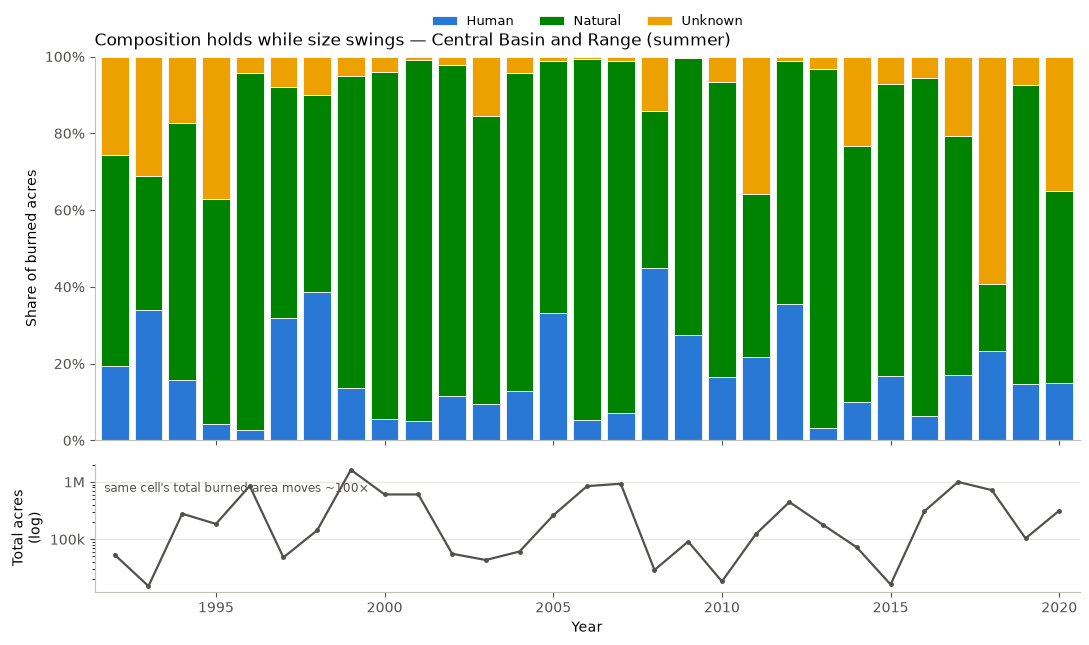

In [12]:
# The flip side: while season SIZE swings wildly, the cause COMPOSITION is comparatively STABLE --
# why the shares baseline scores ~0.27 while the level baseline is ~9x off. One region-season:
# top panel the mix (one stacked bar per year), bottom the SAME cell's total acres (~100x swing).
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

REGION, SEASON = "Central Basin and Range", "JJA"     # a big, megafire-prone region with a genuine
                                                      # three-way mix (not ~100% one class)
YEARS = np.arange(1992, 2021)

d = rsc[(rsc.region == REGION) & (rsc.season == SEASON)]
res = d.groupby(["season_year", "coarse"])["acres"].sum().unstack("coarse", fill_value=0.0)
res["Unknown"] = d.drop_duplicates(["season_year"]).set_index("season_year")["missing_acres"]
res = res.reindex(YEARS).fillna(0.0)
tot = res.sum(axis=1)
sh = res.div(tot, axis=0)[["Human", "Natural", "Unknown"]]    # stack: Human bottom, Natural mid, Unknown top

CLASS_COLORS = {"Human": "#2a78d6", "Natural": "#008300", "Unknown": "#eda100"}   # validated trio

fig, (ax, axb) = plt.subplots(2, 1, figsize=(11, 6.5), height_ratios=[3, 1], sharex=True)

# Top: one stacked bar per year. Thin surface gaps between segments and bars.
bottom = np.zeros(len(YEARS))
for cls in ["Human", "Natural", "Unknown"]:
    ax.bar(YEARS, sh[cls], bottom=bottom, width=0.82, color=CLASS_COLORS[cls],
           label=cls, edgecolor="#fcfcfb", linewidth=0.6)
    bottom += sh[cls].to_numpy()
ax.set_ylim(0, 1)
ax.set_xlim(YEARS[0] - 0.6, YEARS[-1] + 0.6)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Share of burned acres")
ax.set_title(f"Composition holds while size swings — {REGION} (summer)", fontsize=12, loc="left", pad=8)
ax.legend(loc="upper center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.14))
ax.tick_params(colors="#52514e")

# Bottom: the SAME region-season's total acres, for direct contrast.
axb.plot(YEARS, tot.clip(lower=1), color="#52514e", lw=1.6, marker=".", ms=5)
axb.set_yscale("log")
axb.set_ylabel("Total acres\n(log)")
axb.yaxis.set_major_formatter(FuncFormatter(
    lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))
axb.set_xlabel("Year")
axb.grid(True, which="major", axis="y", color="#e6e6e3", lw=0.7)
axb.tick_params(colors="#52514e")
axb.text(0.01, 0.86, "same cell's total burned area moves ~100×", transform=axb.transAxes,
         fontsize=8.5, color="#52514e", va="top")

for a in (ax, axb):
    for sp in ["top", "right"]:
        a.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        a.spines[sp].set_color("#c3c2b7")

fig.tight_layout()
plt.show()

## Does "what kind of region-season is this?" beat persistence?

**Hypothesis.** The baselines predict a cell purely from **its own past**, and found the mix static
and the size nearly unpredictable. If similar region-seasons inform each other, a cross-sectional
model should beat persistence — predicting a cell from *what kind of region-season it is* rather
than from its own timeline.

**Experiment.** Fit gradient-boosted regressors on the trailing fingerprint features from
[`05_features.ipynb`](05_features.ipynb) (`data/region_season_features.parquet`), plus `season` as a
non-leaking identity feature. Every fingerprint feature is a strictly-prior trailing summary,
leakage-audited in that notebook. Same forward-chaining split (train `season_year < 2010`, score
`>= 2010`) and the **same metrics** as the floors — acre-weighted TVD for the composition,
acre-weighted log-MAE for the level — so the comparison is head-to-head on identical cells.

In [13]:
# The feature table carries the trailing fingerprint features AND the Tier-1 targets on the same
# rows, already filtered to the same partial-winter rule applied here.
feats = pd.read_parquet(DATA / "region_season_features.parquet")

# Align the floor to the feature rows by KEY, not position, so the head-to-head is same-cell.
KEY = ["region", "season", "season_idx"]
floor_df = tier1[KEY].copy()
for c in CLASSES:
    floor_df[f"floor_{c}"] = pred_share[c].to_numpy()      # k=7 trailing-mean shares (locked baseline)
feats = feats.merge(floor_df, on=KEY, how="left")

FEATCOLS = [c for c in feats.columns if c.startswith("f_")]

# season is a legitimate, non-leaking identity feature (a cell knows its own season); one-hot it.
X_all = pd.get_dummies(feats[FEATCOLS + ["season"]], columns=["season"], dtype=float)
XCOLS = list(X_all.columns)

# Same forward-chaining split as the floors: train strictly before 2010, score 2010+.
train_mask = (feats["season_year"] < TEST_START).to_numpy()
test_mask  = (feats["season_year"] >= TEST_START).to_numpy()

# A cell is usable only where its trailing features exist. First-occurrence cells are NaN -- the
# same cells the baselines leave unscored, so both sides see the identical tail.
has_feat = feats[FEATCOLS].notna().all(axis=1).to_numpy()
tr = train_mask & has_feat
te = test_mask  & has_feat

wt = feats["total_ac"].to_numpy()                      # acre weights (same weighting as the floors)
print(f"features: {len(XCOLS)} cols ({FEATCOLS} + season one-hot)")
print(f"train cells (<{TEST_START}, with history): {tr.sum():,}")
print(f"test  cells (>={TEST_START}, with history): {te.sum():,}")

features: 12 cols (['f_log_total_mean', 'f_log_total_std', 'f_share_human_mean', 'f_share_natural_mean', 'f_share_unknown_mean', 'f_log_fire_size_mean', 'f_log_nfires_mean', 'f_n_prior'] + season one-hot)
train cells (<2010, with history): 5,399
test  cells (>=2010, with history): 3,941


In [14]:
# One gradient-boosted regressor per class, predictions renormalized onto the simplex (clip
# negatives, divide by the row sum) so the three shares sum to 1 like the target. Scored with the
# SAME acre-weighted TVD as the floor, on the SAME test cells. The mask is `in_test & not-NaN`,
# which keeps the floor and the learned rung on an identical cell population.
from models import SimplexRegressor
from scoring import ladder, score_masked, tvd

Xtr = X_all.to_numpy()[tr]
Xte = X_all.to_numpy()[te]
Ytr = feats[CLASSES].to_numpy()[tr]

P_learn = SimplexRegressor().fit(Xtr, Ytr, sample_weight=wt[tr]).predict(Xte)

A_te = feats[CLASSES].to_numpy()[te]                    # actual shares on the test cells
w_te = wt[te]

# Persistence floor (locked k=7 shares mean), key-aligned onto the same feature rows above, so this
# is a head-to-head on identical cells.
P_floor = feats[[f"floor_{c}" for c in CLASSES]].to_numpy()[te]
assert not np.isnan(P_floor).all(), "floor merged to all-NaN -- check the merge keys"

scorable = np.ones(int(te.sum()), dtype=bool)           # every test row here is scorable
shares_cmp = ladder(
    {
        "persistence floor (k=7)": score_masked(tvd(P_floor, A_te), w_te, scorable),
        "learned (gradient boosting)": score_masked(tvd(P_learn, A_te), w_te, scorable),
    },
    baseline="persistence floor (k=7)",
).rename(columns={"unweighted": "TVD_unweighted", "weighted": "TVD_acre_wtd",
                  "delta_vs_floor": "acre_wtd_delta_vs_floor"})
floor_wtd = shares_cmp.loc["persistence floor (k=7)", "TVD_acre_wtd"]

print(f"SHARES — head-to-head on {te.sum():,} held-out cells (season_year >= {TEST_START})\n")
print(shares_cmp[["TVD_unweighted", "TVD_acre_wtd", "acre_wtd_delta_vs_floor"]].round(4).to_string())
print(f"\nlower TVD = better. negative delta = learned beats the floor.")

SHARES — head-to-head on 3,941 held-out cells (season_year >= 2010)

                             TVD_unweighted  TVD_acre_wtd  acre_wtd_delta_vs_floor
persistence floor (k=7)              0.2676        0.2659                   0.0000
learned (gradient boosting)          0.3141        0.2894                   0.0235

lower TVD = better. negative delta = learned beats the floor.


In [15]:
# A gradient-boosted regressor on log10(total_ac), scored with the SAME acre-weighted log-MAE as
# the level floor -- the hard target, where the floor was ~9x off on the big-burn cells.
# A scalar target, so the sklearn call stays inline (max_iter=400 here, vs the shares' 300).
from sklearn.ensemble import HistGradientBoostingRegressor

from scoring import absolute_error

# Attach the level floor (its own best trailing window, computed in the level sweep) by key.
lvl_floor_df = tier1[KEY].copy()
lvl_floor_df["floor_log"] = pred_log.to_numpy()        # trailing-mean log-acres (level baseline)
lvl_floor_df["actual_log"] = tier1["log_total"].to_numpy()
feats2 = feats.merge(lvl_floor_df, on=KEY, how="left")

ytr_log = feats2["actual_log"].to_numpy()[tr]
yte_log = feats2["actual_log"].to_numpy()[te]

mlvl = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05,
                                     max_leaf_nodes=31, random_state=0)
mlvl.fit(Xtr, ytr_log, sample_weight=wt[tr])
pred_log_learn = mlvl.predict(Xte)
pred_log_floor = feats2["floor_log"].to_numpy()[te]

level_cmp = ladder(
    {
        f"persistence floor ({best_level})": score_masked(
            absolute_error(pred_log_floor, yte_log), w_te, scorable),
        "learned (gradient boosting)": score_masked(
            absolute_error(pred_log_learn, yte_log), w_te, scorable),
    },
    baseline=f"persistence floor ({best_level})",
).rename(columns={"unweighted": "logMAE_unweighted", "weighted": "logMAE_acre_wtd",
                  "delta_vs_floor": "acre_wtd_delta_vs_floor"})
level_cmp["acre_wtd_x_off"] = 10 ** level_cmp["logMAE_acre_wtd"]   # read as "off by ~Nx"
fl_wtd = level_cmp.loc[f"persistence floor ({best_level})", "logMAE_acre_wtd"]

print(f"LEVEL — head-to-head on {te.sum():,} held-out cells (season_year >= {TEST_START})\n")
print(level_cmp[["logMAE_unweighted", "logMAE_acre_wtd", "acre_wtd_x_off",
                 "acre_wtd_delta_vs_floor"]].round(4).to_string())
print(f"\nlower log-MAE = better. negative delta = learned beats the floor.")

LEVEL — head-to-head on 3,941 held-out cells (season_year >= 2010)

                             logMAE_unweighted  logMAE_acre_wtd  acre_wtd_x_off  acre_wtd_delta_vs_floor
persistence floor (k=6)                 0.6352           0.9347          8.6033                    0.000
learned (gradient boosting)             0.9641           0.7767          5.9794                   -0.158

lower log-MAE = better. negative delta = learned beats the floor.


In [16]:
# Ablation verdict: the two deltas against the floors.
sh_delta = shares_cmp.loc["learned (gradient boosting)", "acre_wtd_delta_vs_floor"]
lv_delta = level_cmp.loc["learned (gradient boosting)", "acre_wtd_delta_vs_floor"]

def verdict(delta, floor_val, unit):
    pct = 100 * delta / floor_val
    if delta < -0.005:
        return f"BEATS the floor by {abs(delta):.3f} {unit} ({abs(pct):.1f}% better)"
    if delta > 0.005:
        return f"does NOT beat the floor (worse by {delta:.3f} {unit})"
    return f"TIES the floor (delta {delta:+.3f} {unit}, within noise)"

print("ABLATION LADDER — learned cross-sectional rung vs. persistence floor (acre-weighted)\n")
print(f"  SHARES (cause mix): learned {verdict(sh_delta, floor_wtd, 'TVD')}")
print(f"  LEVEL  (burn size): learned {verdict(lv_delta, fl_wtd, 'log-MAE')}")
print()
print("Reading: a tie on shares confirms the mix signal is already captured by the trailing mean")
print("(the target is static); a tie on the level confirms the missing lift is NOT in the history")
print("-> it points to upcoming-season covariates (weather/drought/fuels), the next rung.")

ABLATION LADDER — learned cross-sectional rung vs. persistence floor (acre-weighted)

  SHARES (cause mix): learned does NOT beat the floor (worse by 0.024 TVD)
  LEVEL  (burn size): learned BEATS the floor by 0.158 log-MAE (16.9% better)

Reading: a tie on shares confirms the mix signal is already captured by the trailing mean
(the target is static); a tie on the level confirms the missing lift is NOT in the history
-> it points to upcoming-season covariates (weather/drought/fuels), the next rung.


## Which predictions can a planner trust? — per-cell confidence from the cell's own history

**Hypothesis.** Every number this notebook reports is a **point estimate averaged over the whole
held-out tail**: "27% of the composition misplaced," "73% top-1." A planner does not receive the
average — they receive *one* region-season, and the deck has no way to say whether that particular
prediction is a good one. No uncertainty is propagated anywhere in the project.

A Dirichlet over the composition is the principled next rung and is not built. But there is a
cheaper quantity already sitting in the baseline: the k=7 window supplies not only a **mean** but a
**dispersion**. If a cell's own prior seven same-season observations were tightly clustered, its
trailing mean is a summary of a settled regime; if they were scattered, the same mean is an average
over a moving target. The hypothesis is that **dispersion of the trailing window predicts the error
of the trailing mean** — and, critically, it is known *before* the target season opens, so it can be
shipped alongside the forecast rather than discovered after scoring.

**Experiment.** For each cell take `TrailingMean(k=7, how="std")` over the same columns, with the
same `shift(1)` and the same `(region, season)` grouping as the prediction itself — so the
dispersion sees exactly the information the forecast saw, and no more. Reduce the per-class standard
deviations to one scalar per cell (their mean), then correlate it against the realized TVD on the
held-out tail. Run it on **both** tiers: the Tier-1 three-class composition here, and the 11-way
human sub-cause composition from [`08_human_cause.ipynb`](08_human_cause.ipynb), which is where the
weaker floor makes a confidence signal most valuable.

Two controls, because a correlation this convenient invites the obvious objections:

- **Shuffled** — permute the dispersion vector against the errors, 200 times. Fixes every marginal
  distribution and breaks only the pairing, so any surviving correlation is the pairing itself.
- **Within-region** — recompute the correlation *inside* each region. Across regions the result
  could merely restate "some regions are stable places," which is geography, not a per-cell signal.
  If it holds within a region's own series, it is genuinely about *this cell in this year*.

In [17]:
# Dispersion of the SAME trailing window that makes the prediction: TrailingMean(k, how="std")
# reuses the identical shift(1) + (region, season) grouping, so it is strictly pre-season
# information. min_periods=2 because a standard deviation needs two observations -- cells with a
# single prior season yield NaN and go unscored rather than being imputed to zero, which would
# read as "perfectly steady" on the thinnest possible evidence.
import warnings

from scipy import stats

from trailing import GROUP_KEYS


def confidence_signal(frame, cols, *, k, weight_col, label):
    """Correlate trailing-window dispersion against realized TVD on the held-out tail.

    Returns the per-cell frame so the caller can bucket it; prints the headline rho, the
    shuffled control and the within-region check.
    """
    f = frame.sort_values(list(cfg.sort_keys)).reset_index(drop=True)
    gk = list(GROUP_KEYS)      # ("region", "season") -- each season is its own series

    P = TrailingMean(k).predict(f, cols, group_keys=gk).to_numpy(dtype=float)
    S = TrailingMean(k, how="std", min_periods=2).predict(f, cols, group_keys=gk).to_numpy(dtype=float)
    A = f[cols].to_numpy(dtype=float)

    err = tvd(P, A)
    # Cells with <2 prior same-season observations are all-NaN across classes, which is the
    # intended "unscored" state -- they are masked out below. np.nanmean warns on those rows;
    # np.errstate does not catch it because it is a Python warning, not an FP flag.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        dispersion = np.nanmean(S, axis=1)      # one scalar per cell: mean per-class sd of its own history

    m = ((f["season_year"] >= TEST_START).to_numpy()
         & ~np.isnan(err) & ~np.isnan(dispersion))

    out = pd.DataFrame({
        "region": f["region"][m], "season": f["season"][m], "season_year": f["season_year"][m],
        "dispersion": dispersion[m], "tvd": err[m], "accuracy": 1 - err[m],
        "weight": f[weight_col].to_numpy()[m],
    })

    rho = stats.spearmanr(out["dispersion"], out["tvd"]).statistic

    # Control 1 -- shuffled: breaks only the dispersion/error pairing.
    rng = np.random.default_rng(0)
    null = np.array([stats.spearmanr(rng.permutation(out["dispersion"]), out["tvd"]).statistic
                     for _ in range(200)])
    sd_above = (rho - null.mean()) / null.std()

    # Control 2 -- within-region: is this a per-cell signal or just "some regions are stable"?
    within = (out.groupby("region")
                 .filter(lambda t: len(t) >= 20)
                 .groupby("region")
                 .apply(lambda t: stats.spearmanr(t["dispersion"], t["tvd"]).statistic,
                        include_groups=False)
                 .dropna())

    print(f"{label}  ({len(out):,} held-out cells with >=2 prior same-season observations)")
    print(f"   Spearman(dispersion, TVD)  = {rho:+.3f}")
    print(f"   shuffled control           = {null.mean():+.4f} +/- {null.std():.4f}  "
          f"-> {sd_above:.0f} SD above chance")
    print(f"   within-region              = median rho {within.median():+.3f}, "
          f"{(within > 0).sum()}/{len(within)} of regions positive (n>=20)")
    return out


tier1_conf = confidence_signal(tier1, CLASSES, k=SHARE_K, weight_col="total_ac",
                               label=f"TIER 1 -- 3-class composition, k={SHARE_K}")
print()
human_shares, HUMAN_COLS = panel.human_subcause_shares()
human_conf = confidence_signal(human_shares.assign(_w=1.0), HUMAN_COLS, k=SHARE_K, weight_col="_w",
                               label=f"HUMAN  -- {len(HUMAN_COLS)}-cause composition, k={SHARE_K}")

/var/folders/hr/t1_4y5dd3nqgxcj6kn65dgdm0000gn/T/ipykernel_36426/114878948.py:26: RuntimeWarning: Mean of empty slice
  dispersion = np.nanmean(S, axis=1)      # one scalar per cell: mean per-class sd of its own history


TIER 1 -- 3-class composition, k=7  (3,941 held-out cells with >=2 prior same-season observations)
   Spearman(dispersion, TVD)  = +0.484
   shuffled control           = +0.0011 +/- 0.0145  -> 33 SD above chance
   within-region              = median rho +0.175, 74/93 of regions positive (n>=20)

HUMAN  -- 11-cause composition, k=7  (3,844 held-out cells with >=2 prior same-season observations)
   Spearman(dispersion, TVD)  = +0.577
   shuffled control           = -0.0020 +/- 0.0167  -> 35 SD above chance
   within-region              = median rho +0.267, 80/92 of regions positive (n>=20)


/var/folders/hr/t1_4y5dd3nqgxcj6kn65dgdm0000gn/T/ipykernel_36426/114878948.py:26: RuntimeWarning: Mean of empty slice
  dispersion = np.nanmean(S, axis=1)      # one scalar per cell: mean per-class sd of its own history


In [18]:
# What the signal is worth in practice: split held-out cells into quartiles by their own
# pre-season dispersion and score each bucket separately. p10 is carried because a planner's
# question is not "how good is this on average" but "how bad does it get" -- the bad tail is
# what a confidence flag is for.

def confidence_buckets(conf, label):
    q = pd.qcut(conf["dispersion"], 4,
                labels=["Q1 steadiest", "Q2", "Q3", "Q4 most volatile"])
    table = (conf.assign(bucket=q)
                 .groupby("bucket", observed=True)
                 .apply(lambda t: pd.Series({
                     "n_cells": len(t),
                     "mean_accuracy": t["accuracy"].mean(),
                     "acre_wtd_accuracy": (np.average(t["accuracy"], weights=t["weight"])
                                           if t["weight"].sum() > 0 else np.nan),
                     "p10_accuracy": np.percentile(t["accuracy"], 10),
                     "worst_case": t["accuracy"].min(),
                 }), include_groups=False))
    spread = table["mean_accuracy"].iloc[0] - table["mean_accuracy"].iloc[-1]
    print(f"{label}   (accuracy = 1 - TVD, i.e. share of the composition placed correctly)\n")
    print(table.assign(
        n_cells=table["n_cells"].astype(int),
        **{c: (table[c] * 100).round(1).astype(str) + "%"
           for c in ["mean_accuracy", "acre_wtd_accuracy", "p10_accuracy", "worst_case"]},
    ).to_string())
    print(f"\n   steadiest minus most volatile: {spread * 100:.1f} accuracy points\n")
    return table


t1_buckets = confidence_buckets(tier1_conf, "TIER 1 -- 3-class composition")
hu_buckets = confidence_buckets(human_conf, "HUMAN  -- 11-cause composition")

TIER 1 -- 3-class composition   (accuracy = 1 - TVD, i.e. share of the composition placed correctly)

                  n_cells mean_accuracy acre_wtd_accuracy p10_accuracy worst_case
bucket                                                                           
Q1 steadiest          986         83.1%             88.9%        58.2%       0.0%
Q2                    985         77.5%             72.9%        52.7%       0.0%
Q3                    985         70.5%             71.4%        40.5%       5.3%
Q4 most volatile      985         61.9%             59.0%        35.7%       5.7%

   steadiest minus most volatile: 21.2 accuracy points

HUMAN  -- 11-cause composition   (accuracy = 1 - TVD, i.e. share of the composition placed correctly)

                  n_cells mean_accuracy acre_wtd_accuracy p10_accuracy worst_case
bucket                                                                           
Q1 steadiest          961         72.5%             72.5%        47.6%       0.0%


In [19]:
# One region, four seasons, four different confidence levels -- the grouping is (region, season),
# so Klamath winter never informs Klamath summer. This is what makes the signal usable: the unit a
# planner acts on is a region-season, and the same region can be trustworthy in one season and not
# in another.
KL = "Klamath Mountains/California High North Coast Range"

kl = (tier1_conf[tier1_conf["region"] == KL]
      .groupby("season", observed=True)
      .apply(lambda t: pd.Series({
          "n_held_out": len(t),
          "mean_dispersion": t["dispersion"].mean(),
          "mean_accuracy": t["accuracy"].mean(),
      }), include_groups=False)
      .sort_values("mean_dispersion"))

print(f"{KL}\n")
print(kl.assign(n_held_out=kl["n_held_out"].astype(int),
                mean_dispersion=kl["mean_dispersion"].round(3),
                mean_accuracy=(kl["mean_accuracy"] * 100).round(1).astype(str) + "%").to_string())
print("\nSteadier seasons score better within this one region -- summer is the volatile one,")
print("which is where lightning competes with human ignition and the mix genuinely moves.")

# The counterexample, and it matters more than the trend: the signal ranks, it does not guarantee.
# A quiet history can precede a regime break, and when it does the confident-looking cell is the
# one that misses worst.
worst = tier1_conf.nlargest(5, "tvd")[["region", "season", "season_year", "dispersion", "accuracy"]]
steady_cut = tier1_conf["dispersion"].quantile(0.25)
trap = tier1_conf[(tier1_conf["dispersion"] <= steady_cut) & (tier1_conf["accuracy"] < 0.25)]

print(f"\n\nCounterexample -- cells in the steadiest quartile (dispersion <= {steady_cut:.3f}) "
      f"that still scored below 25% accuracy: {len(trap)} of {(tier1_conf['dispersion'] <= steady_cut).sum():,}"
      f" ({len(trap) / (tier1_conf['dispersion'] <= steady_cut).sum():.1%})")
print(trap.nsmallest(5, "accuracy")[["region", "season", "season_year", "dispersion", "accuracy"]]
        .assign(dispersion=lambda d: d["dispersion"].round(3),
                accuracy=lambda d: (d["accuracy"] * 100).round(1).astype(str) + "%")
        .to_string(index=False))

Klamath Mountains/California High North Coast Range

        n_held_out  mean_dispersion mean_accuracy
season                                           
DJF             11            0.121         75.8%
SON             11            0.180         63.1%
MAM             11            0.216         79.8%
JJA             11            0.293         57.3%

Steadier seasons score better within this one region -- summer is the volatile one,
which is where lightning competes with human ignition and the mix genuinely moves.


Counterexample -- cells in the steadiest quartile (dispersion <= 0.124) that still scored below 25% accuracy: 36 of 986 (3.7%)
                                region season  season_year  dispersion accuracy
                        Copper Plateau    SON         2012       0.000     0.0%
                      Seward Peninsula    JJA         2016       0.000     0.0%
                    Wrangell Mountains    MAM         2011       0.000     0.0%
Interior Forested Lowlands and

**Finding.** **A cell's own history variance predicts how wrong its forecast will be, and it is
known before the season opens.** Dispersion of the k=7 window correlates with realized TVD at
Spearman **+0.484** on Tier 1 and **+0.577** on the human sub-causes — **33 and 35 SD** above a
shuffled control, so this is not an artifact of the marginal distributions.

**It is a per-cell signal, not a restatement of geography.** Within individual regions it holds in
**74 of 93** (Tier 1) and **80 of 92** (Human) of the series long enough to test, at median rho
+0.175 and +0.267. So it is not merely that some regions are stable places; within one region's own
timeline, the years following a volatile stretch are the years the forecast misses.

**What it buys, in quartiles of pre-season dispersion:**

| | Tier 1 steadiest → most volatile | Human steadiest → most volatile |
|---|---|---|
| mean accuracy | **83.1% → 61.9%** (21.2 points) | **72.5% → 39.4%** (33.0 points) |
| p10 accuracy | 58.2% → 35.7% | 47.6% → 14.4% |

The spread is **half again as wide on the human branch**, which is where it is most needed: the
11-way floor is the weaker product, and this says its failures are anticipated rather than random.
A planner can be handed the ranked profile *with a flag* — this region-season has been settled,
treat the ranking as firm; this one has been swinging, treat it as provisional.

**The grouping is `(region, season)`, so each season is its own series and carries its own
confidence.** Klamath is the worked example: winter dispersion 0.121 at 75.8% accuracy, summer 0.293
at 57.3%. One region, four seasons, four different levels of trust — and summer, where lightning
competes with human ignition, is the volatile one. Note MAM scores highest (79.8%) despite
mid-range dispersion: **within a single region of eleven held-out years the ordering is noisy**, and
the claim is a population-level one.

**The honest limit — it ranks confidence, it does not calibrate it.** The correct statement is "this
cell sits in the steadiest quartile, which historically scored 83%," never "this prediction is 83%
likely to be right." And a quiet history is not a guarantee: **36 of 986 steadiest-quartile cells
(3.7%) still scored below 25%**, several at dispersion exactly 0.000 — a cell can be perfectly
settled right up until the regime breaks, and those are the confident-looking misses. A Dirichlet
over the composition remains the principled rung for genuine intervals; this is a cheaper signal
that happens to be available for free from the baseline already in use.